In [21]:
import pandas as pd
import numpy as np 
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns

In [22]:
df = pd.read_csv(r"C:\Users\tejas\Downloads\CO2 Concentration.xls")
df.head()

,Year,Month,CO2 Concentration
0,1975,1,330.62
1,1975,2,331.40
2,1975,3,331.87
3,1975,4,333.18
4,1975,5,333.92


In [23]:
df.shape

(144, 3)

In [24]:
df['Year_Month'] = df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2)
df.head()

,Year,Month,CO2 Concentration,Year_Month
0,1975,1,330.62,1975-01
1,1975,2,331.40,1975-02
2,1975,3,331.87,1975-03
3,1975,4,333.18,1975-04
4,1975,5,333.92,1975-05


In [25]:
df["Year_Month"] = pd.to_datetime(df["Year_Month"])
df = df.set_index("Year_Month")

In [26]:
df.drop(columns = ['Year', 'Month'], inplace = True)

In [27]:
df.head()

,CO2 Concentration
Year_Month,
1975-01-01,330.62
1975-02-01,331.40
1975-03-01,331.87
1975-04-01,333.18
1975-05-01,333.92


Text(0, 0.5, 'CO2 Concentration')

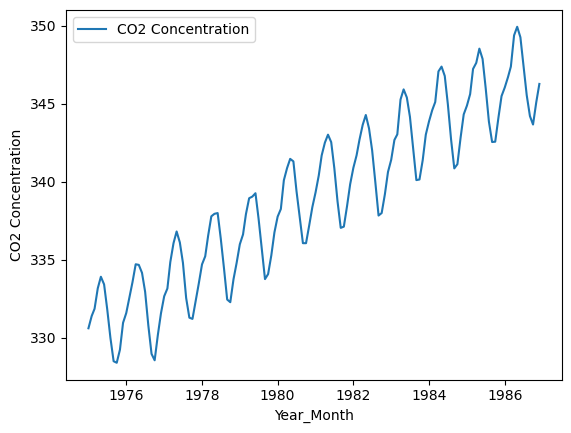

In [28]:
sns.lineplot(df)
plt.ylabel('CO2 Concentration')

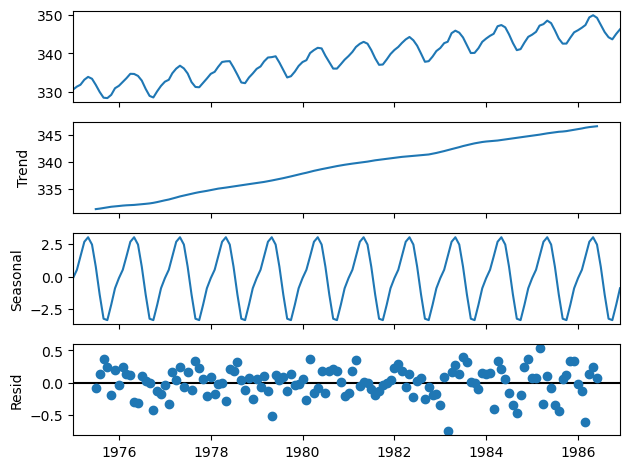

In [29]:
result = seasonal_decompose(df[['CO2 Concentration']],
                            model = 'additive',
                            period = 12)
result.plot()
plt.show()